In [50]:
# =========================
# Task 1: Imports & Setup
# =========================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)


# =========================
# Task 2: Load Data
# =========================
csv_path = '/content/DataCoSupplyChainDataset_Cleaned/DataCoSupplyChainDataset_Cleaned.csv'
df = pd.read_csv(csv_path, encoding='latin1')
print(f"[INFO] Loaded {df.shape[0]:,} rows × {df.shape[1]} cols")
display(df.head())


[INFO] Loaded 180,519 rows × 168 cols


,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Department Id,Latitude,Longitude,Order Item Cardprod Id,Order Item Discount,...,Order Status_COMPLETE,Order Status_ON_HOLD,Order Status_PAYMENT_REVIEW,Order Status_PENDING,Order Status_PENDING_PAYMENT,Order Status_PROCESSING,Order Status_SUSPECTED_FRAUD,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class
0,3,4,91.250000,314.640015,0,2,18.251453,-66.037056,1360,13.110000,...,True,False,False,False,False,False,False,False,False,True
1,5,4,-249.089996,311.359985,1,2,18.279451,-66.037064,1360,16.389999,...,False,False,False,True,False,False,False,False,False,True
2,4,4,-247.779999,309.720001,0,2,37.292233,-121.881279,1360,18.030001,...,False,False,False,False,False,False,False,False,False,True
3,3,4,22.860001,304.809998,0,2,34.125946,-118.291016,1360,22.940001,...,True,False,False,False,False,False,False,False,False,True
4,2,4,134.210007,298.250000,0,2,18.253769,-66.037048,1360,29.500000,...,False,False,False,False,True,False,False,False,False,True


In [51]:
# ============================================
# Task 3: Build X/y (Classification, no leakage)
# ============================================
target_col = "Late_delivery_risk"  # 0 = on-time, 1 = late
y = df[target_col].astype(int)

# Drop regression targets that could leak unrelated signals
drop_cols = [
    "Order Profit Per Order", "Order Item Total", "Product Price"
]

#  Drop post-outcome columns that can leak the label
leak_status_prefixes = ["Delivery Status_", "Order Status_"]
status_cols = [c for c in df.columns if any(c.startswith(p) for p in leak_status_prefixes)]

X_raw = df.drop(columns=[c for c in (drop_cols + status_cols + [target_col]) if c in df.columns])

# Keep numeric features and any existing bool dummies (0/1 after cast)
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
bool_cols = [c for c in X_raw.columns if X_raw[c].dtype == bool]
X_num = X_raw[num_cols].copy()
X_cat = X_raw[bool_cols].astype('int8') if bool_cols else pd.DataFrame(index=X_raw.index)

X = pd.concat([X_num, X_cat], axis=1)
print(f"[BUILD] Features: {X.shape[1]} | Rows: {X.shape[0]}")


[BUILD] Features: 153 | Rows: 180519


In [52]:
# =========================
# Task 4: Train/Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Class balance (train):")
print(y_train.value_counts(normalize=True).round(3))


Train: (144415, 153), Test: (36104, 153)
Class balance (train):
Late_delivery_risk
1    0.548
0    0.452
Name: proportion, dtype: float64


In [53]:
# =========================
# Task 5: Scaling
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [ ]:
# =========================
# Task 6: Build ANN (Classification)
# =========================
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    # Dropout(0.1),  
    Dense(1, activation='sigmoid')  # binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │         2,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609 (10.19 KB)

 Trainable params: 2,609 (10.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5285 - loss: 0.7084 - val_accuracy: 0.7350 - val_loss: 0.5749
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7867 - loss: 0.5059 - val_accuracy: 0.9164 - val_loss: 0.3007
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9379 - loss: 0.2499 - val_accuracy: 0.9585 - val_loss: 0.1800
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9636 - loss: 0.1576 - val_accuracy: 0.9661 - val_loss: 0.1374
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9690 - loss: 0.1220 - val_accuracy: 0.9692 - val_loss: 0.1158
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9712 - loss: 0.1038 - val_accuracy: 0.9701 - val_loss: 0.1058
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9721 - loss: 0.0942 - val_accuracy: 0.9707 - val_loss: 0.0999
Epoch 8/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9731 - loss: 0.0878 - val_accuracy: 0.

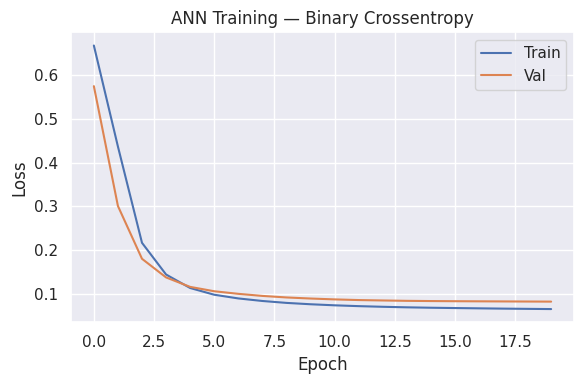

In [ ]:
# =========================
# Task 7: Train + Learning Curves
# =========================
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    epochs=20,            
    batch_size=1024,      
    validation_split=0.2,
    callbacks=[es],
    verbose=1
)

# Plot loss curves
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('ANN Training — Binary Crossentropy')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


1129/1129 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
=== ANN (Classification) — Test Metrics ===
Accuracy : 0.9735
Precision: 0.9557
Recall   : 0.9979
F1-score : 0.9763
ROC AUC  : 0.9935


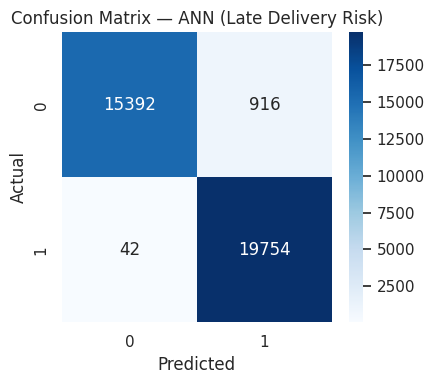

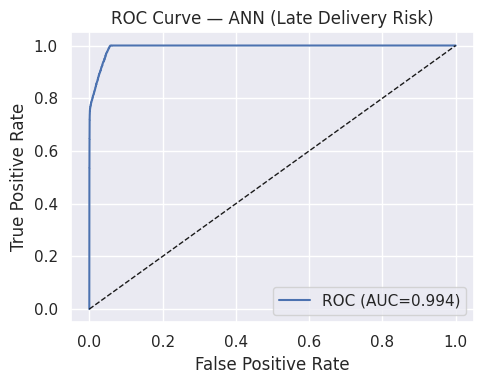

In [56]:
# =========================
# Task 8: Evaluation (Accuracy, Precision, Recall, F1, AUC)
# =========================
y_proba = model.predict(X_test_scaled).ravel()
y_pred  = (y_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1  = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print("=== ANN (Classification) — Test Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC AUC  : {auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — ANN (Late Delivery Risk)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'ROC (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — ANN (Late Delivery Risk)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()
